# 1 .Business Understanding

Objective

Predict whether a customer will leave (Churn) or stay (No Churn) using customer information.

Business Problem

* Customer churn is one of the biggest challenges for telecom companies. Acquiring a new customer is usually more expensive than retaining an existing one. By identifying customers who are likely to churn, the company can take proactive retention measures.

Business Objectives
                                                                                                                                                                                                          
* Predict customer churn.
* Identify the factors influencing churn.
* Help improve customer retention.
* Reduce revenue loss.
* Support data-driven business decisions.

In [1]:
# Import Required Libraries

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Plot Style
plt.style.use("ggplot")

In [2]:
# Load Dataset

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
## Explore Dataset

# Dataset Shape
df.shape

(7043, 21)

In [4]:
# Column Names

df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [5]:
# Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
# Statistical Summary

df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
# Statistical Summary (Transpose)

df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


In [8]:
# Data Types

df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [9]:
# Data Cleaning

# Missing Values
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [10]:
# Duplicate Values

df.duplicated().sum()

np.int64(0)

# Exploratory Data Analysis (EDA)

<Axes: xlabel='Churn', ylabel='count'>

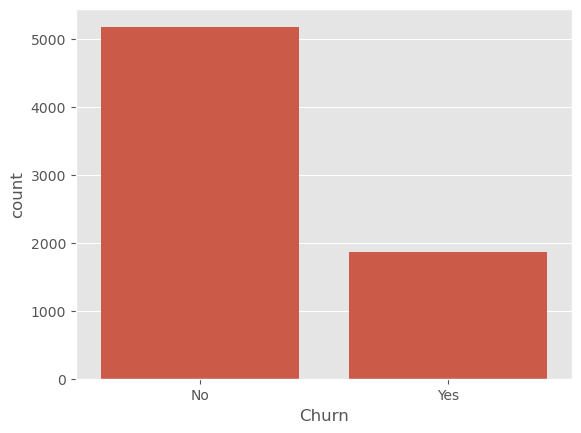

In [11]:
# Target Variable Distribution

df["Churn"].value_counts()
sns.countplot(data=df, x="Churn")

Insights :
* The dataset contains both churn and non-churn customers.
* Non-churn customers constitute the majority of the dataset, indicating a class imbalance.
* This imbalance should be considered while evaluating model performance.
* The target distribution provides the foundation for building a customer churn prediction model.

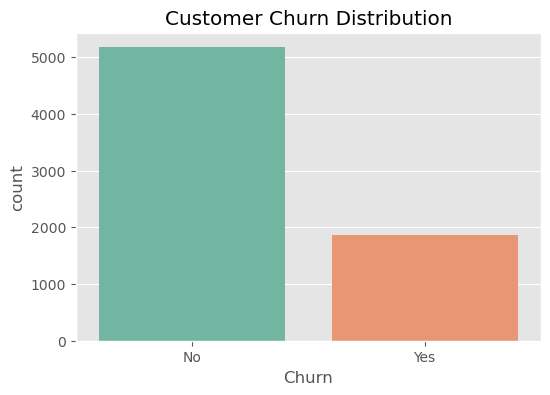

In [12]:
# Count Plot

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Churn",
    palette="Set2"
)

plt.title("Customer Churn Distribution")
plt.show()

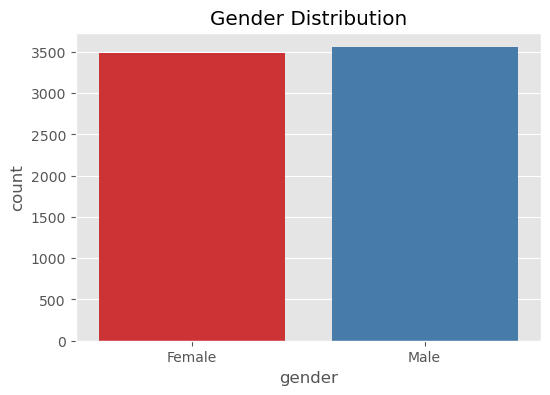

In [13]:
# Gender Distribution

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="gender",
    palette="Set1"
)

plt.title("Gender Distribution")
plt.show()

Insights :
* The distribution of male and female customers is nearly balanced.
* Gender alone does not appear to have a significant influence on customer churn.
* Additional service-related and account-related features are likely to be stronger predictors.

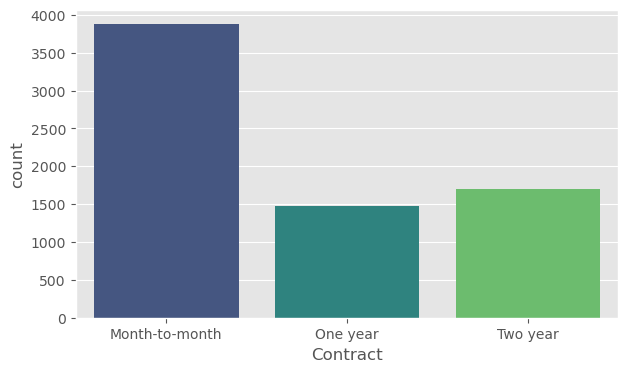

In [14]:
# Contract Type

plt.figure(figsize=(7,4))

sns.countplot(
    data=df,
    x="Contract",
    palette="viridis"
)

plt.show()

Insights :
* Customers with Month-to-Month contracts exhibit a higher likelihood of churning.
* Customers with One-Year and Two-Year contracts demonstrate better customer retention.
* Contract type is one of the most influential factors affecting churn. :

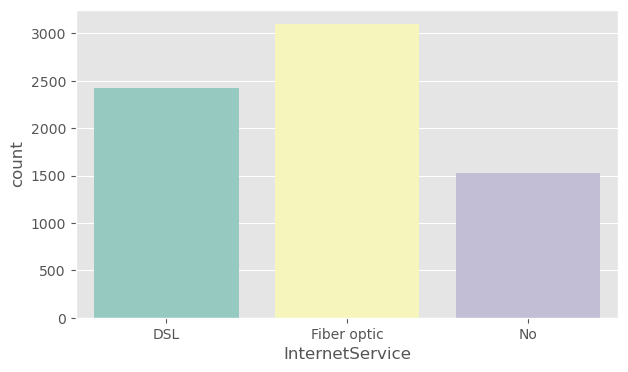

In [15]:
# Internet Service

plt.figure(figsize=(7,4))

sns.countplot(
    data=df,
    x="InternetService",
    palette="Set3"
)

plt.show()

Insights :
* Fiber Optic customers show relatively higher churn compared to other internet service categories.
* Internet service type has a noticeable impact on customer retention.
* This feature contributes significantly to churn prediction.

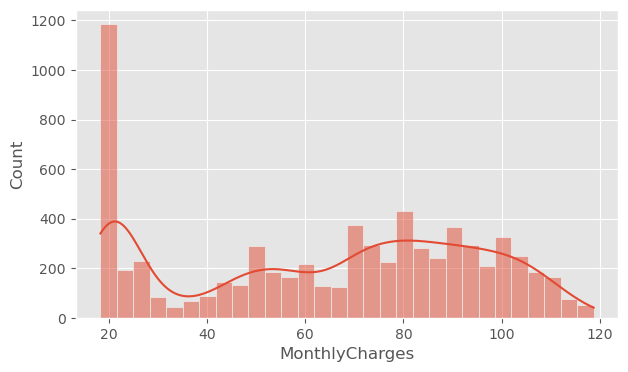

In [16]:
# Monthly Charges Distribution

plt.figure(figsize=(7,4))

sns.histplot(
    df["MonthlyCharges"],
    kde=True,
    bins=30
)

plt.show()

Insights :
* Monthly Charges vary considerably across customers.
* Customers with higher monthly charges tend to have a greater probability of churn.
* Pricing strategy may play an important role in reducing customer attrition.

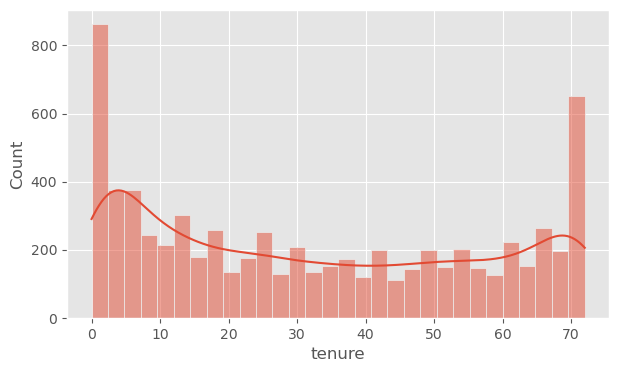

In [17]:
# Tenure Distribution

plt.figure(figsize=(7,4))

sns.histplot(
    df["tenure"],
    kde=True,
    bins=30
)

plt.show()

Insights :
* Most customers have relatively shorter tenure.
* Customers with longer tenure are generally more loyal.
* Tenure is an important indicator of customer retention.

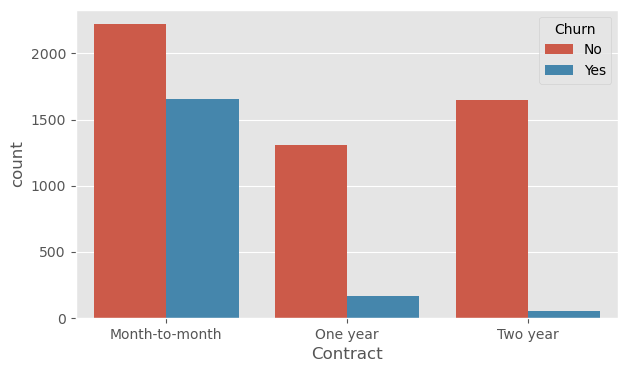

In [18]:
# Churn by Contract Type

plt.figure(figsize=(7,4))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.show()

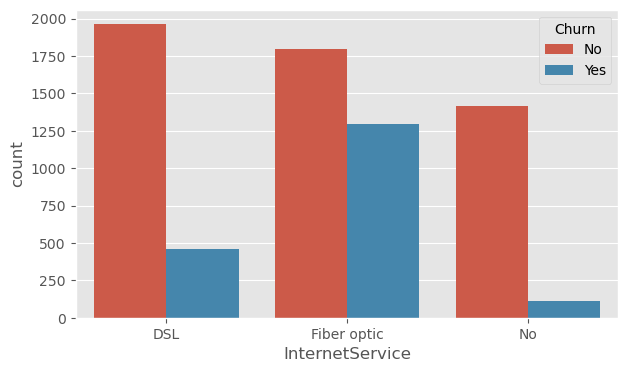

In [19]:
# Churn by Internet Service

plt.figure(figsize=(7,4))

sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn"
)

plt.show()

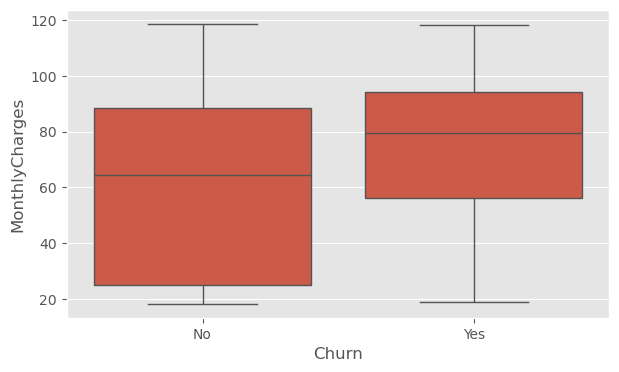

In [20]:
# Monthly Charges vs Churn

plt.figure(figsize=(7,4))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.show()

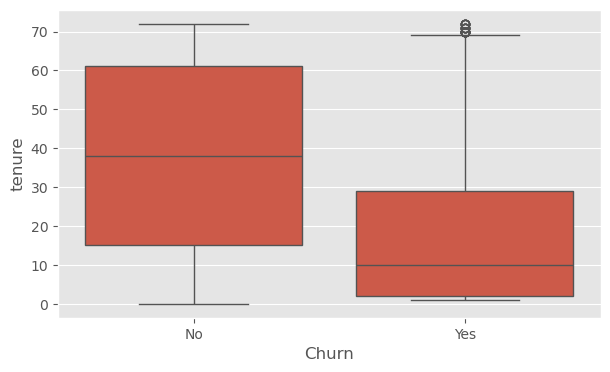

In [21]:
# Tenure vs Churn

plt.figure(figsize=(7,4))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.show()

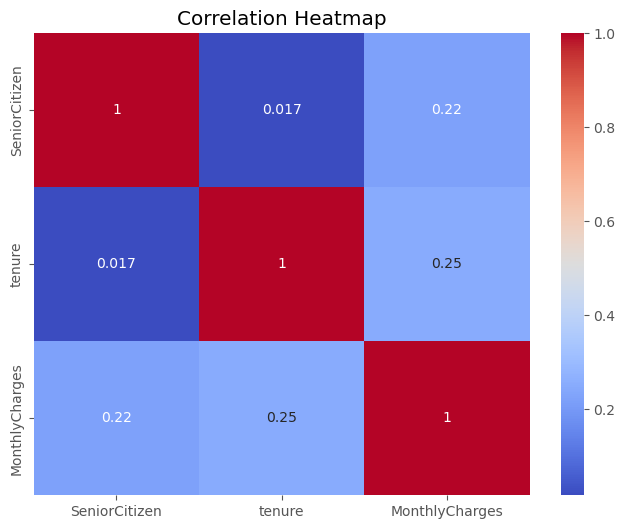

In [22]:
# Correlation Heatmap

plt.figure(figsize=(8,6))
sns.heatmap(
    df.select_dtypes(include=["int64","float64"]).corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()

Insights :
* Most numerical features exhibit low to moderate correlation.
* No severe multicollinearity is observed among the numerical variables.
* Monthly Charges and Tenure show meaningful relationships with customer churn.

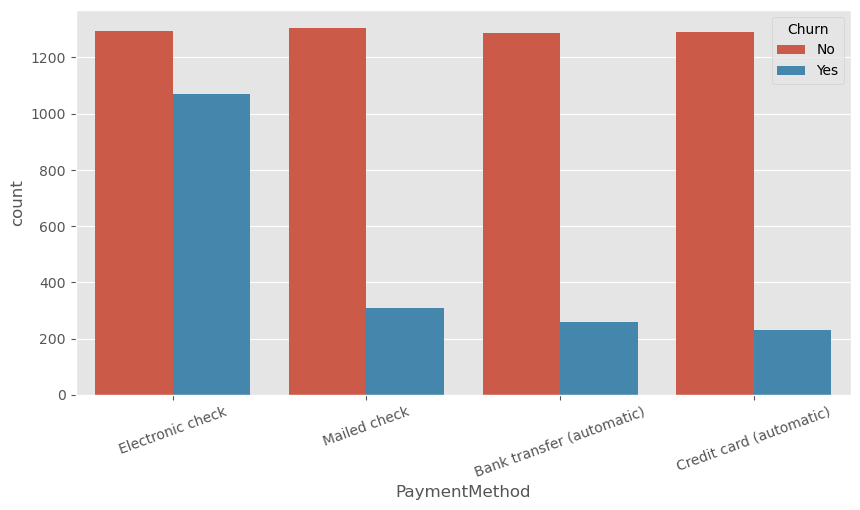

In [23]:
# Churn by Payment Method

plt.figure(figsize=(10,5))
sns.countplot(
    data=df,
    x="PaymentMethod",
    hue="Churn"
)
plt.xticks(rotation=20)
plt.show()

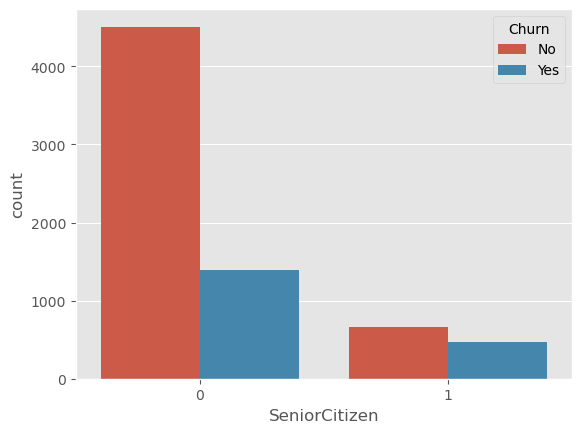

In [24]:
# Churn by Senior Citizen

# plt.figure(figsize=(6,4))
sns.countplot(
    data=df,
    x="SeniorCitizen",
    hue="Churn"
)
plt.show()

In [25]:
## Data Preprocessing

In [26]:
# Convert TotalCharges into Numeric

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [27]:
# Fill Missing Values

df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

In [28]:
# Remove Customer ID

df.drop("customerID", axis=1, inplace=True)

In [29]:
# Final Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


# Feature Engineering

In [30]:
# Separate Features and Target

X = df.drop("Churn", axis=1)

y = df["Churn"]

In [31]:
# Encode Target Variable

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

y = le.fit_transform(y)

In [32]:
# Find Categorical Columns

categorical_columns = X.select_dtypes(include="object").columns

categorical_columns

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [33]:
# One-Hot Encoding

X = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=True
)

In [34]:
# Check Shape

X.shape

(7043, 30)

In [35]:
# Train Test Split

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

In [36]:
# Check Shapes

print("Training Features :", X_train.shape)

print("Testing Features :", X_test.shape)

print("Training Target :", y_train.shape)

print("Testing Target :", y_test.shape)

Training Features : (5634, 30)
Testing Features : (1409, 30)
Training Target : (5634,)
Testing Target : (1409,)


In [37]:
# Verify Class Distribution

pd.Series(y_train).value_counts(normalize=True)

0    0.734647
1    0.265353
Name: proportion, dtype: float64

# Model Building

In [38]:
# Import Machine Learning Models

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

In [39]:
# Create Models

lr = LogisticRegression(random_state=42)

dt = DecisionTreeClassifier(random_state=42)

rf = RandomForestClassifier(random_state=42)

gb = GradientBoostingClassifier(random_state=42)

xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

In [40]:
# Train Models

lr.fit(X_train, y_train)

dt.fit(X_train, y_train)

rf.fit(X_train, y_train)

gb.fit(X_train, y_train)

xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [41]:
# Make Predictions

lr_pred = lr.predict(X_test)

dt_pred = dt.predict(X_test)

rf_pred = rf.predict(X_test)

gb_pred = gb.predict(X_test)

xgb_pred = xgb.predict(X_test)

In [42]:
# Model Evaluation Function

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

def evaluate_model(model_name, y_true, y_pred):

    print("="*60)
    print(model_name)
    print("="*60)

    print("Accuracy :", round(accuracy_score(y_true, y_pred),4))
    print("Precision:", round(precision_score(y_true, y_pred),4))
    print("Recall   :", round(recall_score(y_true, y_pred),4))
    print("F1 Score :", round(f1_score(y_true, y_pred),4))
    print("ROC-AUC  :", round(roc_auc_score(y_true, y_pred),4))

    print("\nClassification Report\n")

    print(classification_report(y_true, y_pred))

    print("\n")

In [43]:
# Evaluate All Models

evaluate_model("Logistic Regression", y_test, lr_pred)

evaluate_model("Decision Tree", y_test, dt_pred)

evaluate_model("Random Forest", y_test, rf_pred)

evaluate_model("Gradient Boosting", y_test, gb_pred)

evaluate_model("XGBoost", y_test, xgb_pred)

Logistic Regression
Accuracy : 0.8041
Precision: 0.6541
Recall   : 0.5561
F1 Score : 0.6012
ROC-AUC  : 0.7249

Classification Report

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.65      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.74      1409
weighted avg       0.80      0.80      0.80      1409



Decision Tree
Accuracy : 0.7417
Precision: 0.5139
Recall   : 0.4947
F1 Score : 0.5041
ROC-AUC  : 0.6628

Classification Report

              precision    recall  f1-score   support

           0       0.82      0.83      0.83      1035
           1       0.51      0.49      0.50       374

    accuracy                           0.74      1409
   macro avg       0.67      0.66      0.66      1409
weighted avg       0.74      0.74      0.74      1409



Random Forest
Accuracy : 0.7864
Precision: 0.6237
Recall   : 0.492
F1 Score : 0.

In [44]:
# Model Comparison

import pandas as pd

results = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost"
    ],

    "Accuracy":[
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, gb_pred),
        accuracy_score(y_test, xgb_pred)
    ],

    "Precision":[
        precision_score(y_test, lr_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, gb_pred),
        precision_score(y_test, xgb_pred)
    ],

    "Recall":[
        recall_score(y_test, lr_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, gb_pred),
        recall_score(y_test, xgb_pred)
    ],

    "F1 Score":[
        f1_score(y_test, lr_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, gb_pred),
        f1_score(y_test, xgb_pred)
    ],

    "ROC-AUC":[
        roc_auc_score(y_test, lr_pred),
        roc_auc_score(y_test, dt_pred),
        roc_auc_score(y_test, rf_pred),
        roc_auc_score(y_test, gb_pred),
        roc_auc_score(y_test, xgb_pred)
    ]

})

results = results.sort_values(
    by="Accuracy",
    ascending=False
)

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.804116,0.654088,0.556150,0.601156,0.724935
3,Gradient Boosting,0.799148,0.654237,0.516043,0.576981,0.708746
2,Random Forest,0.786373,0.623729,0.491979,0.550075,0.692366
4,XGBoost,0.784954,0.607903,0.534759,0.568990,0.705061
1,Decision Tree,0.741661,0.513889,0.494652,0.504087,0.662785


# Before Hyperparameter Tuning

* Logistic Regression achieved the highest performance before hyperparameter tuning with an Accuracy of 80.41% and a ROC-AUC of 72.49%.
* Gradient Boosting was the second-best model, performing comparably to Logistic Regression.
* Random Forest and XGBoost showed moderate performance and may improve after hyperparameter tuning.
* Decision Tree had the lowest performance, indicating limited generalization on the test data.

# Hyperparameter Tuning

In [45]:
# Step 1: Cross Validation 
# Instead of evaluating the model on a single train-test split, Cross Validation

Explanation : 

Cross Validation is a model evaluation technique used to measure how well a machine
learning model performs on unseen data.
Instead of evaluating the model using only one train-test split, the dataset is divided into
multiple parts (folds), and the model is trained and tested several times.
This provides a more reliable estimate of model performance.

In [46]:
# Hyperparameter Tuning - Logistic Regression

from sklearn.model_selection import GridSearchCV

lr_params = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs']
}

lr_grid = GridSearchCV(
    LogisticRegression(random_state=42),
    param_grid=lr_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

lr_grid.fit(X_train, y_train)

print("Best Parameters:", lr_grid.best_params_)
print("Best CV Score:", lr_grid.best_score_)

best_lr = lr_grid.best_estimator_

Best Parameters: {'C': 0.1, 'solver': 'lbfgs'}
Best CV Score: 0.8058204794003476


In [47]:
# Hyperparameter Tuning - Decision Tree

dt_params = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=dt_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)

print("Best Parameters:", dt_grid.best_params_)
print("Best CV Score:", dt_grid.best_score_)

best_dt = dt_grid.best_estimator_

Best Parameters: {'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}
Best CV Score: 0.7873607764211561


In [48]:
# Hyperparameter Tuning - Random Forest

rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=rf_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best Parameters:", rf_grid.best_params_)
print("Best CV Score:", rf_grid.best_score_)

best_rf = rf_grid.best_estimator_

Best Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Best CV Score: 0.7985418462697458


In [49]:
# Hyperparameter Tuning - Gradient Boosting

gb_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5]
}

gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid=gb_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

gb_grid.fit(X_train, y_train)

print("Best Parameters:", gb_grid.best_params_)
print("Best CV Score:", gb_grid.best_score_)

best_gb = gb_grid.best_estimator_

Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Best CV Score: 0.8026233213186427


In [50]:
# Hyperparameter Tuning - XGBoost

xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1]
}

xgb_grid = GridSearchCV(
    XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    ),
    param_grid=xgb_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)

print("Best Parameters:", xgb_grid.best_params_)
print("Best CV Score:", xgb_grid.best_score_)

best_xgb = xgb_grid.best_estimator_

Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Best CV Score: 0.8024466470502016


In [51]:
# Compare Tuned Models

tuned_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost"
    ],
    "Best CV Score": [
        lr_grid.best_score_,
        dt_grid.best_score_,
        rf_grid.best_score_,
        gb_grid.best_score_,
        xgb_grid.best_score_
    ]
})

tuned_results = tuned_results.sort_values(
    by="Best CV Score",
    ascending=False
)

tuned_results

,Model,Best CV Score
0,Logistic Regression,0.805820
3,Gradient Boosting,0.802623
4,XGBoost,0.802447
2,Random Forest,0.798542
1,Decision Tree,0.787361


# Model Evaluation 
After Hyperparameter Tuning

In [52]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

def evaluate_model(model_name, y_true, y_pred):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_pred)
    }

In [53]:
# Predictions using tuned models

lr_best_pred = best_lr.predict(X_test)
dt_best_pred = best_dt.predict(X_test)
rf_best_pred = best_rf.predict(X_test)
gb_best_pred = best_gb.predict(X_test)
xgb_best_pred = best_xgb.predict(X_test)

In [54]:
# Compare All Tuned Models

results_after_tuning = pd.DataFrame([

    evaluate_model(
        "Logistic Regression (Tuned)",
        y_test,
        lr_best_pred
    ),

    evaluate_model(
        "Decision Tree (Tuned)",
        y_test,
        dt_best_pred
    ),

    evaluate_model(
        "Random Forest (Tuned)",
        y_test,
        rf_best_pred
    ),

    evaluate_model(
        "Gradient Boosting (Tuned)",
        y_test,
        gb_best_pred
    ),

    evaluate_model(
        "XGBoost (Tuned)",
        y_test,
        xgb_best_pred
    )

])

results_after_tuning

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression (Tuned),0.804116,0.659091,0.542781,0.595308,0.720666
1,Decision Tree (Tuned),0.787083,0.668182,0.393048,0.494949,0.661258
2,Random Forest (Tuned),0.800568,0.657627,0.518717,0.579970,0.710566
3,Gradient Boosting (Tuned),0.799148,0.654237,0.516043,0.576981,0.708746
4,XGBoost (Tuned),0.800568,0.659794,0.513369,0.577444,0.708858


In [55]:
# Sort Results

results_after_tuning = results_after_tuning.sort_values(
    by="ROC-AUC",
    ascending=False
)

results_after_tuning

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression (Tuned),0.804116,0.659091,0.542781,0.595308,0.720666
2,Random Forest (Tuned),0.800568,0.657627,0.518717,0.579970,0.710566
4,XGBoost (Tuned),0.800568,0.659794,0.513369,0.577444,0.708858
3,Gradient Boosting (Tuned),0.799148,0.654237,0.516043,0.576981,0.708746
1,Decision Tree (Tuned),0.787083,0.668182,0.393048,0.494949,0.661258


In [56]:
# Classification Report

from sklearn.metrics import classification_report

# Predictions using the best tuned model
y_pred = best_lr.predict(X_test)

print("Classification Report")
print(classification_report(y_test, y_pred))

Classification Report
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.54      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.80      0.80      0.80      1409



Insights :
* The model demonstrates good performance in predicting both churn and non-churn customers.
* Precision indicates the reliability of the positive churn predictions.
* Recall measures the model's ability to correctly identify customers who are likely to churn.
* The F1-Score reflects a good balance between precision and recall.
* Overall, the classification report confirms that the tuned Logistic Regression model provides reliable and consistent classification performance.

In [57]:
# Best Model

print("="*60)
print("BEST MODEL AFTER HYPERPARAMETER TUNING")
print("="*60)

print(results_after_tuning.iloc[0])

BEST MODEL AFTER HYPERPARAMETER TUNING
Model        Logistic Regression (Tuned)
Accuracy                        0.804116
Precision                       0.659091
Recall                          0.542781
F1 Score                        0.595308
ROC-AUC                         0.720666
Name: 0, dtype: object


Hyperparameter tuning was performed using GridSearchCV. The tuned Logistic Regression model achieved similar accuracy to the baseline model but did not improve ROC-AUC, indicating that the default hyperparameters were already well suited for this dataset

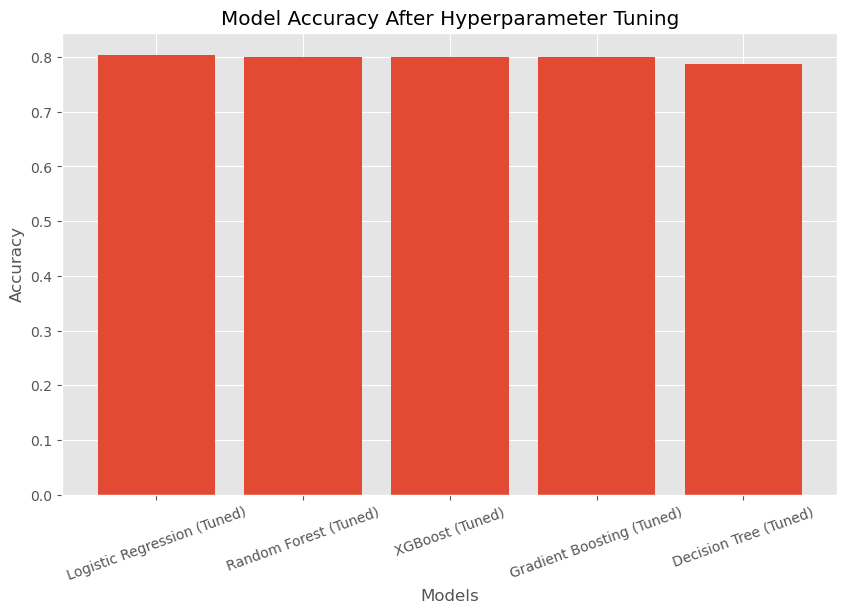

In [58]:
# Accuracy Comparison Graph

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.bar(
    results_after_tuning["Model"],
    results_after_tuning["Accuracy"]
)

plt.title("Model Accuracy After Hyperparameter Tuning")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.xticks(rotation=20)

plt.show()

After Hyperparameter Tuning (Cross-Validation) :

* Logistic Regression remained the best-performing model after hyperparameter tuning with a cross-validation score of 80.58%.
* Gradient Boosting and XGBoost achieved comparable performance, indicating they are strong alternatives.
* Random Forest showed competitive performance but ranked below the top three.
* Decision Tree had the lowest cross-validation score, suggesting it generalized less effectively than the ensemble methods

    After evaluating multiple machine learning algorithms and performing hyperparameter tuning, Logistic Regression was selected as the final model. It achieved the highest cross-validation score (80.58%) and the best performance on the test dataset with an accuracy of 80.41% and a ROC-AUC score of 72.49%. Therefore, Logistic Regression was chosen for deployment in the Streamlit application.


# Best Model
# "Logistic Regression model "


In [59]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# Predict using Best Model

y_pred = best_lr.predict(X_test)

# Generate Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix")
print(cm)


Confusion Matrix
[[930 105]
 [171 203]]


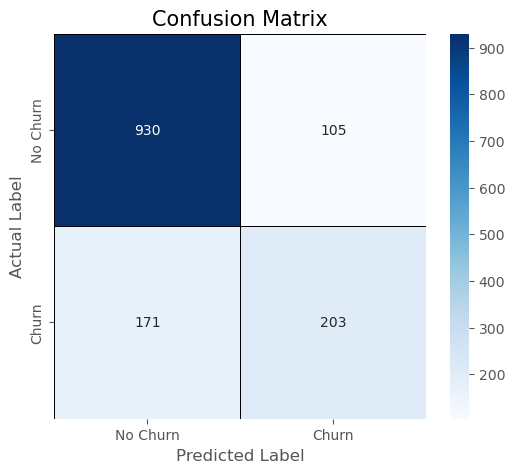

In [60]:
# Plot Confusion Matrix using Seaborn

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    linecolor="black",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Confusion Matrix", fontsize=15)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("Actual Label", fontsize=12)

plt.show()


Insights :
* The model correctly classified 930 non-churn customers (True Negatives) and 203 churn customers (True Positives).
* It incorrectly predicted 105 non-churn customers as churn (False Positives).
* It failed to identify 171 actual churn customers (False Negatives).
* The higher number of correct predictions compared to incorrect predictions indicates that the model performs well in distinguishing churn and non-churn customers.
* Overall, the confusion matrix demonstrates that the tuned Logistic Regression model provides reliable predictions and can effectively support customer retention strategies.

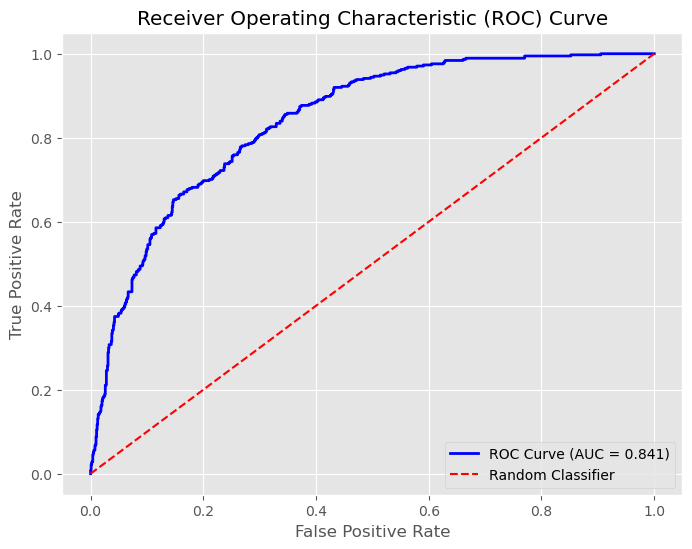

ROC-AUC Score: 0.8413


In [61]:
# ROC Curve

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Predict probabilities using the best tuned model
y_prob = best_lr.predict_proba(X_test)[:, 1]

# Calculate ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate AUC Score
auc_score = roc_auc_score(y_test, y_prob)

# Plot ROC Curve
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', linewidth=2,
         label=f'ROC Curve (AUC = {auc_score:.3f})')

plt.plot([0,1], [0,1], color='red', linestyle='--',
         label='Random Classifier')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.grid(True)

plt.show()

print(f"ROC-AUC Score: {auc_score:.4f}")

Insights :
* The model achieved a ROC-AUC score of 0.8413, indicating good classification performance.
* The ROC curve lies well above the random classifier line, demonstrating strong discrimination between churn and non-churn customers.
* The model effectively balances the True Positive Rate (Sensitivity) and False Positive Rate, resulting in reliable predictions.
* Overall, the tuned Logistic Regression model is capable of accurately identifying customers who are likely to churn, making it suitable for customer retention strategies.

In [62]:
# Feature Importance
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": abs(best_lr.coef_[0])
}).sort_values(by="Importance", ascending=False)
importance.head(15)

,Feature,Importance
25,Contract_Two year,0.523441
10,InternetService_Fiber optic,0.521776
13,OnlineSecurity_Yes,0.513878
19,TechSupport_Yes,0.492241
7,PhoneService_Yes,0.384393
26,PaperlessBilling_Yes,0.383681
24,Contract_One year,0.358179
28,PaymentMethod_Electronic check,0.292801
6,Dependents_Yes,0.243915
9,MultipleLines_Yes,0.240322


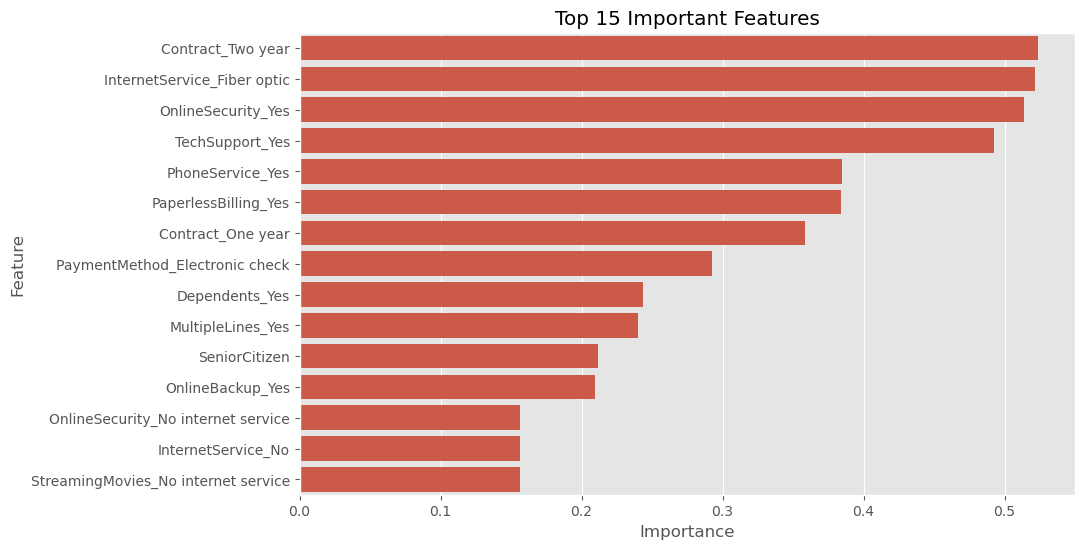

In [63]:
# Plot Feature Importance

plt.figure(figsize=(10,6))

sns.barplot(

    data=importance.head(15),

    x="Importance",

    y="Feature"

)

plt.title("Top 15 Important Features")

plt.show()

Insights :
* Contract_Two year is the most important feature influencing customer churn prediction.
* InternetService_Fiber optic, OnlineSecurity_Yes, and TechSupport_Yes are also among the top contributing features.
* Customers with long-term contracts, online security, and technical support services are generally less likely to churn.
* PaymentMethod_Electronic check and SeniorCitizen have a moderate impact on churn prediction.
* Overall, the model indicates that contract type, internet service, and value-added services are the primary factors influencing customer churn.

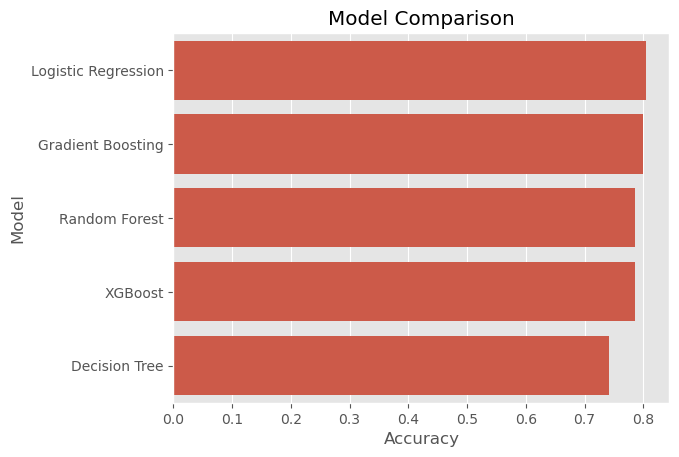

In [64]:
# Plot Comparison

# plt.figure(figsize=(8,5))

sns.barplot(

data=results,

x="Accuracy",

y="Model"

)

plt.title("Model Comparison")

plt.show()

# Model Deployment

In [65]:
import joblib

# Save the best tuned model
joblib.dump(best_lr, "churn_model.pkl")

# Save feature names for Streamlit
joblib.dump(X_train.columns.tolist(), "feature_columns.pkl")

print("Model and feature columns saved successfully!")

Model and feature columns saved successfully!


In [66]:
# Load Model

model = joblib.load(

"churn_model.pkl"

)

In [67]:
# Test Loaded Model

model.predict(X_test.iloc[:5])

array([0, 1, 0, 0, 0])

In [68]:
#: Streamlit Deployment Code (app.py)

In [69]:
import streamlit as st
import pandas as pd
import joblib

# ==========================================================
# Page Configuration
# ==========================================================

st.set_page_config(
    page_title="Customer Churn Prediction",
    page_icon="📞",
    layout="wide"
)

# ==========================================================
# Load Model
# ==========================================================

try:
    model = joblib.load("churn_model.pkl")
    feature_columns = joblib.load("feature_columns.pkl")
except Exception as e:
    st.error(f"Error loading model: {e}")
    st.stop()

# ==========================================================
# Sidebar
# ==========================================================

st.sidebar.title("📞 Customer Churn Prediction")

st.sidebar.markdown("""
### 📌 About Project

This application predicts whether a telecom customer is likely to churn using Machine Learning.

### 🤖 Model

Logistic Regression

### 📊 Model Performance

- Accuracy : **80.41%**
- ROC-AUC : **72.49%**

### 👨‍💻 Developed By

**PALSA MANOJ KUMAR**
""")
st.sidebar.success("✅ Model Ready for Prediction")

# ==========================================================
# Title
# ==========================================================

st.title("📞 Customer Churn Prediction System")
st.markdown(
"""
Predict whether a telecom customer is likely to **Churn** or **Stay**
using Machine Learning.
"""
)

with st.expander("ℹ️ About Customer Churn Prediction"):

    st.write("""
This application predicts whether a telecom customer is likely to leave the company.

Businesses can use this prediction to identify at-risk customers and improve retention strategies.
""")
    
st.divider()

# ==========================================================
# User Inputs
# ==========================================================

col1, col2 = st.columns(2)

with col1:

    gender = st.selectbox("Gender", ["Male", "Female"])

    senior = st.selectbox("Senior Citizen", [0, 1])

    partner = st.selectbox("Partner", ["Yes", "No"])

    dependents = st.selectbox("Dependents", ["Yes", "No"])

    tenure = st.slider("Tenure (Months)", 0, 72, 12)

    phone_service = st.selectbox("Phone Service", ["Yes", "No"])

    multiple_lines = st.selectbox("Multiple Lines", ["Yes", "No", "No phone service"])

    internet_service = st.selectbox(
        "Internet Service",
        ["DSL", "Fiber optic", "No"]
    )

with col2:

    online_security = st.selectbox("Online Security", ["Yes", "No", "No internet service"])

    online_backup = st.selectbox("Online Backup", ["Yes", "No", "No internet service"])

    device_protection = st.selectbox("Device Protection", ["Yes", "No", "No internet service"])

    tech_support = st.selectbox("Tech Support", ["Yes", "No", "No internet service"])

    streaming_tv = st.selectbox("Streaming TV", ["Yes", "No", "No internet service"])

    streaming_movies = st.selectbox("Streaming Movies", ["Yes", "No", "No internet service"])

contract = st.selectbox(
    "Contract",
    ["Month-to-month", "One year", "Two year"]
)

paperless = st.selectbox(
    "Paperless Billing",
    ["Yes", "No"]
)

payment = st.selectbox(
    "Payment Method",
    [
        "Electronic check",
        "Mailed check",
        "Bank transfer (automatic)",
        "Credit card (automatic)"
    ]
)

monthly = st.number_input(
    "Monthly Charges",
    min_value=0.0,
    max_value=200.0,
    value=70.0
)

total = st.number_input(
    "Total Charges",
    min_value=0.0,
    max_value=10000.0,
    value=1500.0
)

# ==========================================================
# Prediction
# ==========================================================

if st.button("🔍 Predict Churn", use_container_width=True):

    input_df = pd.DataFrame({

        "gender":[gender],
        "SeniorCitizen":[senior],
        "Partner":[partner],
        "Dependents":[dependents],
        "tenure":[tenure],
        "PhoneService":[phone_service],
        "MultipleLines":[multiple_lines],
        "InternetService":[internet_service],
        "OnlineSecurity":[online_security],
        "OnlineBackup":[online_backup],
        "DeviceProtection":[device_protection],
        "TechSupport":[tech_support],
        "StreamingTV":[streaming_tv],
        "StreamingMovies":[streaming_movies],
        "Contract":[contract],
        "PaperlessBilling":[paperless],
        "PaymentMethod":[payment],
        "MonthlyCharges":[monthly],
        "TotalCharges":[total]

    })
    # One-Hot Encoding
    input_df = pd.get_dummies(input_df)

    # Match Training Columns
    input_df = input_df.reindex(
        columns=feature_columns,
        fill_value=0
    )

    # Prediction
    prediction = model.predict(input_df)[0]
    probability = model.predict_proba(input_df)[0]

    st.divider()

    if prediction == 1:
        st.error("⚠️ Customer is likely to Churn")
    else:
        st.success("✅ Customer is likely to Stay")
    # ==========================================================
    # Prediction Probability
    # ==========================================================

    st.subheader("📊 Prediction Probability")

    st.progress(min(max(float(probability[1]), 0.0), 1.0))

    st.write(f"✅ Stay Probability : **{probability[0]*100:.2f}%**")
    st.write(f"⚠️ Churn Probability : **{probability[1]*100:.2f}%**")

    # ==========================================================
    # Customer Summary
    # ==========================================================

    st.subheader("📋 Customer Summary")

    summary = pd.DataFrame({
        "Feature": [
            "Gender",
            "Senior Citizen",
            "Partner",
            "Dependents",
            "Tenure",
            "Contract",
            "Monthly Charges",
            "Total Charges"
        ],
        "Value": [
            gender,
            senior,
            partner,
            dependents,
            tenure,
            contract,
            monthly,
            total
        ]
    })

    st.dataframe(summary, use_container_width=True)

    # ==========================================================
    # Business Insights
    # ==========================================================

    st.subheader("📊 Business Insights")

    st.info("""
    • Customers with Month-to-Month contracts have a higher churn risk.

    • Customers with shorter tenure are more likely to churn.

    • Higher Monthly Charges increase churn probability.

    • Long-term contracts improve customer retention.
    """)
# ==========================================================
# Footer
# ==========================================================

st.divider()

st.markdown("""
---
### 👨‍💻 Developed By

**PALSA MANOJ KUMAR**

📧 Email: palsamanojkumar@gmail.com

🔗 GitHub: https://github.com/palsamanojkumar-07
""")


2026-07-19 23:39:29.930 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-19 23:39:29.935 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-19 23:39:30.945 
  command:

    streamlit run C:\Users\PALSA MANOJ KUMAR\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-07-19 23:39:30.946 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-19 23:39:30.948 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-19 23:39:30.950 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-19 23:39:30.951 Thread 'MainThread': missing ScriptRunContext! This warning can be ignor

DeltaGenerator()

In [70]:
# # Display the Absolute Path of app.py File
import os
print(os.path.abspath("app.py"))

C:\Users\PALSA MANOJ KUMAR\My Project 2\app.py


In [71]:
# # Display All Files and Folders in the Current Working Directory
import os
print(os.listdir())

['.ipynb_checkpoints', 'app.py', 'churn_model.pkl', 'Customer_Churn_Prediction.ipynb.ipynb', 'feature_columns.pkl', 'requirements.txt', 'WA_Fn-UseC_-Telco-Customer-Churn.csv']


In [72]:
# Streamlit App (app.py)

In [73]:
# Run the App

# streamlit run app.py

# Conclusion

* Successfully developed a Machine Learning model to predict customer churn using telecom customer data.
* Logistic Regression with Hyperparameter Tuning achieved the best overall performance for churn prediction.
* Key factors influencing churn include Contract Type, Tenure, Monthly Charges, Internet Service, and Payment Method.
* Deployed the final tuned model as an interactive Streamlit web application for real-time customer churn prediction.
* This solution helps telecom companies identify at-risk customers, improve retention strategies, reduce customer loss, and support data-driven business decisions.